# HW02

Датасет: Drug Classification<br>
Описание: This database contains information about certain drug types.<br>
[Ссылка на датасет](https://www.kaggle.com/datasets/prathamtripathi/drug-classification)

Сюда вставлю проверку из прошлого ноутбука. Чтобы спалось спокойнее.

In [2]:
import sys
import platform

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

%matplotlib inline

try:
    import sklearn
    from sklearn.feature_extraction import FeatureHasher
except Exception as e:
    sklearn = None
    print("⚠️ scikit-learn не импортируется:", e)

print("Python:", sys.version.split()[0])
print("Executable:", sys.executable)
print("OS:", platform.platform())

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
if sklearn is not None:
    print("scikit-learn:", sklearn.__version__)

Python: 3.12.3
Executable: /media/chalandbek/4 soft/4soft/gcppc/ml-course-homeworks/.venv/bin/python
OS: Linux-6.17.0-14-generic-x86_64-with-glibc2.39
NumPy: 2.4.2
Pandas: 3.0.1
scikit-learn: 1.8.0


Загрузка датасета

In [3]:
drugs = pd.read_csv("drug200.xls")

>Я не уверен, что каждое действие нужно расписывать отдельным блоком. Тем не менее я буду.

Проверка датасета:
* Первые 5 строк
* Последние 5 строк
* Количество строк и столбцов

In [4]:
print(drugs.head(), '\n')
print(drugs.tail(), '\n')
print(drugs.shape, '\n')

   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  DrugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  DrugY 

     Age Sex      BP Cholesterol  Na_to_K   Drug
195   56   F     LOW        HIGH   11.567  drugC
196   16   M     LOW        HIGH   12.006  drugC
197   52   M  NORMAL        HIGH    9.894  drugX
198   23   M  NORMAL      NORMAL   14.020  drugX
199   40   F     LOW      NORMAL   11.349  drugX 

(200, 6) 



Информация о датасете и описание (Отдельно для строковых данных)

In [5]:
print(drugs.info(), '\n')
print(drugs.describe(), '\n')
print(drugs.describe(include="object"), '\n')

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB
None 

              Age     Na_to_K
count  200.000000  200.000000
mean    44.315000   16.084485
std     16.544315    7.223956
min     15.000000    6.269000
25%     31.000000   10.445500
50%     45.000000   13.936500
75%     58.000000   19.380000
max     74.000000   38.247000 

        Sex    BP Cholesterol   Drug
count   200   200         200    200
unique    2     3           2      5
top       M  HIGH        HIGH  DrugY
freq    104    77         103     91 



/tmp/ipykernel_9295/2287247392.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(drugs.describe(include="object"), '\n')


В сим датасете все значения присутствуют. Вот пруфы:

In [6]:
drugs.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

Для наглядности дальнейших заданий очень желательны пропуски. Посему я просто заполню рандомные ячейки NA-значениями.

In [7]:
np.random.seed(42)

for col in drugs.columns.to_list():
    nMissing = int(len(drugs) * 0.1)
    missingIndices = np.random.choice(drugs.index, size=nMissing, replace=False)
    drugs.loc[missingIndices, col] = np.nan

isnull() для обнаружения пропущенных значений, .sum() для подсчета общего количества пропущенных значений.

In [8]:
print(drugs.isnull(), "\n")
print(drugs.isnull().sum(), "\n")

       Age    Sex     BP  Cholesterol  Na_to_K   Drug
0    False  False  False        False    False  False
1    False  False  False        False    False  False
2    False  False   True        False    False   True
3    False  False  False        False    False   True
4    False   True  False        False    False  False
..     ...    ...    ...          ...      ...    ...
195  False  False  False        False    False  False
196  False  False  False        False    False  False
197  False  False   True        False    False  False
198  False  False  False        False    False  False
199  False  False  False        False    False  False

[200 rows x 6 columns] 

Age            20
Sex            20
BP             20
Cholesterol    20
Na_to_K        20
Drug           20
dtype: int64 



dropna() для удаления неугодных столбцов

In [9]:
drugsD = drugs.copy()
drugsD = drugsD.dropna()
print(drugsD.shape)

(107, 6)


Заполнение NA-значений
* Age - mean (к счастью, люди долго не живут и выбросов быть не должно, посему можно просто брать среднее значение)
* Sex, BP, Cholesterol, Drug: mode (поскольку это не числовые данные и других вариантов, кроме самого частого значения, в данном случае нет).
* Na_to_K: median (А вот тут я не биолог, чего ожидать я не знаю, посему от греха подальше поставлю median)

In [10]:
drugsF = drugs
drugsAgeMean = drugsF['Age'].mean()
drugsSexMode = drugsF['Sex'].mode()[0]
drugsBPMode = drugsF['BP'].mode()[0]
drugsCholesterolMode = drugsF['Cholesterol'].mode()[0]
drugsDrugMode = drugsF['Drug'].mode()[0]
drugsNa_to_KMedian = drugsF['Na_to_K'].median()

fill_values = {
    'Age': drugsAgeMean,
    'Sex': drugsSexMode,
    'BP': drugsBPMode,
    'Cholesterol': drugsCholesterolMode,
    'Drug': drugsDrugMode,
    'Na_to_K': drugsNa_to_KMedian
}
print(drugsF.head(), '\n')

drugsF = drugsF.fillna(fill_values)

print(drugsF.head())


    Age  Sex      BP Cholesterol  Na_to_K   Drug
0  23.0    F    HIGH        HIGH   25.355  DrugY
1  47.0    M     LOW        HIGH   13.093  drugC
2  47.0    M     NaN        HIGH   10.114    NaN
3  28.0    F  NORMAL        HIGH    7.798    NaN
4  61.0  NaN     LOW        HIGH   18.043  DrugY 

    Age Sex      BP Cholesterol  Na_to_K   Drug
0  23.0   F    HIGH        HIGH   25.355  DrugY
1  47.0   M     LOW        HIGH   13.093  drugC
2  47.0   M    HIGH        HIGH   10.114  DrugY
3  28.0   F  NORMAL        HIGH    7.798  DrugY
4  61.0   M     LOW        HIGH   18.043  DrugY


Для колонок с численными данными выводятся:
* минимальное значение
* максимальное значение
* среднее значение
* медианное значение
* самое частое значение

In [11]:
for colName in drugsF.columns.tolist():
    col = drugsF[colName]
    if col.dtype.kind in 'iuf':
        print(colName, ':')
        print('\tmin :', col.min())
        print('\tmax :', col.max())
        print('\tmean :', col.mean())
        print('\tmedian :', col.median())
        print('\tmode :', col.mode()[0])

Age :
	min : 15.0
	max : 74.0
	mean : 44.861111111111114
	median : 44.861111111111114
	mode : 44.861111111111114
Na_to_K :
	min : 6.269
	max : 38.247
	mean : 15.874589999999998
	median : 13.9365
	mode : 13.9365


In [12]:
for colName in drugsF.columns.to_list():
    col = drugs[colName]
    if(col.dtype.kind in 'iuf'):
        print(col.quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

0.05    20.0
0.25    32.0
0.50    45.0
0.75    58.0
0.95    72.0
Name: Age, dtype: float64
0.05     7.84265
0.25    10.44525
0.50    13.93650
0.75    19.25775
0.95    31.69550
Name: Na_to_K, dtype: float64


Для численных данных считаются
* дисперсия
* асимметрия
* эксцесс

Из вывода видно, что возраст распределен очень равномерно, симметрично, без резких пиков.
Отношение натрия к калию менее симметрично и имеет куда более острый пик, что является признаком выбросов.
> То есть методы заполнения NA-значений я выбрал вполне удачно)

In [13]:
for colName in drugsF.columns.to_list():
    col = drugsF[colName]
    if(col.dtype.kind in 'iuf'):
        print(colName, ':')
        print('\tVariance: ', col.var())
        print('\tSkewness:', col.skew())
        print('\tKurtosis:', col.kurt())

Age :
	Variance:  240.31923506420992
	Skewness: 0.019954761468646838
	Kurtosis: -0.8363569381667815
Na_to_K :
	Variance:  48.06751191648242
	Skewness: 1.2200519958468579
	Kurtosis: 0.9464533491913052


Преобразование категориальных признаков в индикаторные
> +8 столбцов)

In [14]:
drugsE = pd.get_dummies(drugsF)
print(drugsE.head())

    Age  Na_to_K  Sex_F  Sex_M  BP_HIGH  BP_LOW  BP_NORMAL  Cholesterol_HIGH  \
0  23.0   25.355   True  False     True   False      False              True   
1  47.0   13.093  False   True    False    True      False              True   
2  47.0   10.114  False   True     True   False      False              True   
3  28.0    7.798   True  False    False   False       True              True   
4  61.0   18.043  False   True    False    True      False              True   

   Cholesterol_NORMAL  Drug_DrugY  Drug_drugA  Drug_drugB  Drug_drugC  \
0               False        True       False       False       False   
1               False       False       False       False        True   
2               False        True       False       False       False   
3               False        True       False       False       False   
4               False        True       False       False       False   

   Drug_drugX  
0       False  
1       False  
2       False  
3       False  


Преобразование категориальных признаков в числовые. Для удобства вывод оригинальных и преобразованных столбцов рядом

In [15]:
drugsLE = drugsF.copy()
shownCategories = []
for colName in drugsLE.columns.to_list():
    col = drugsLE[colName]
    if(not(col.dtype.kind in 'iuf')):
        colEnName = colName + '_encoded'
        drugsLE[colEnName] = col.astype('category').cat.codes
        shownCategories.append(colName)
        shownCategories.append(colEnName)
print(drugsLE[shownCategories].head(10))

  Sex  Sex_encoded      BP  BP_encoded Cholesterol  Cholesterol_encoded  \
0   F            0    HIGH           0        HIGH                    0   
1   M            1     LOW           1        HIGH                    0   
2   M            1    HIGH           0        HIGH                    0   
3   F            0  NORMAL           2        HIGH                    0   
4   M            1     LOW           1        HIGH                    0   
5   F            0  NORMAL           2        HIGH                    0   
6   F            0  NORMAL           2        HIGH                    0   
7   M            1     LOW           1        HIGH                    0   
8   M            1  NORMAL           2        HIGH                    0   
9   M            1     LOW           1      NORMAL                    1   

    Drug  Drug_encoded  
0  DrugY             0  
1  drugC             3  
2  DrugY             0  
3  DrugY             0  
4  DrugY             0  
5  drugX             4  

я понял как делать Feature Hashing с использованием sklearn, но во взятом мною датасете ни один из признаков не принимает более 5 уникальных значений, т.е. в данной фиче смысла +-0.

Просто пара новых колонок (в задании сказали так сделать)

In [16]:
drugsN = drugsF.copy()
drugsN['Na_to_K_per_Y'] = drugsN['Na_to_K'] / drugsN['Age']
drugsN['BP_Cholesterol'] = drugsN['BP']+ '/' + drugsN['Cholesterol']

print(drugsN.head())

    Age Sex      BP Cholesterol  Na_to_K   Drug  Na_to_K_per_Y BP_Cholesterol
0  23.0   F    HIGH        HIGH   25.355  DrugY       1.102391      HIGH/HIGH
1  47.0   M     LOW        HIGH   13.093  drugC       0.278574       LOW/HIGH
2  47.0   M    HIGH        HIGH   10.114  DrugY       0.215191      HIGH/HIGH
3  28.0   F  NORMAL        HIGH    7.798  DrugY       0.278500    NORMAL/HIGH
4  61.0   M     LOW        HIGH   18.043  DrugY       0.295787       LOW/HIGH


Далее графики. Они подписаны, посему смысла дописывать сюда что-то я не вижу.

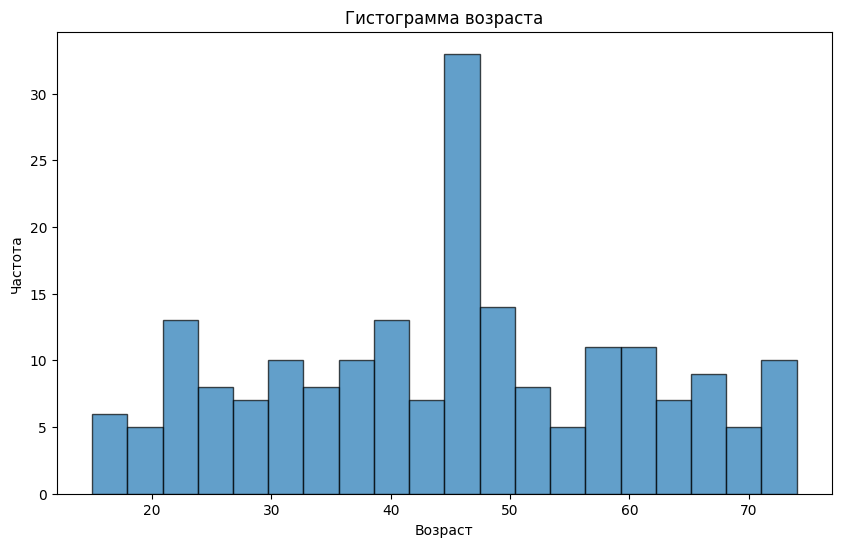

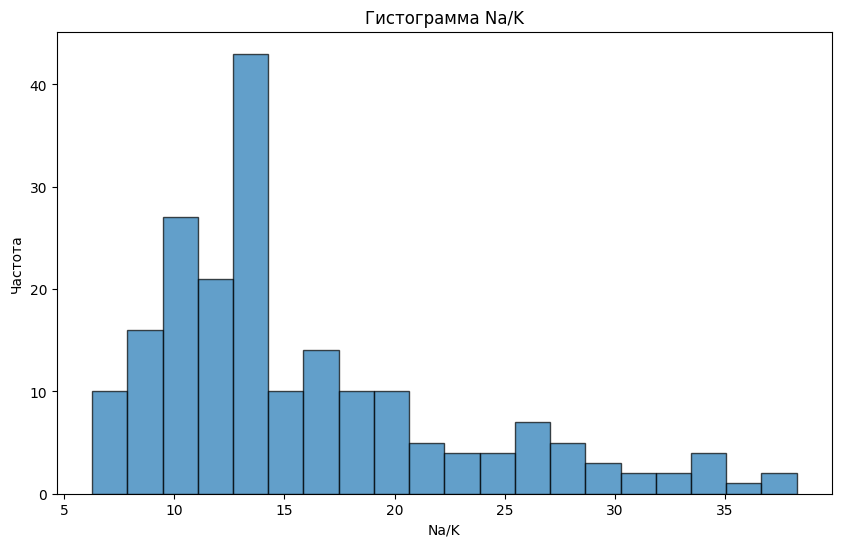

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(drugsF['Age'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Гистограмма возраста')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(drugsF['Na_to_K'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Гистограмма Na/K')
plt.xlabel('Na/K')
plt.ylabel('Частота')
plt.show()

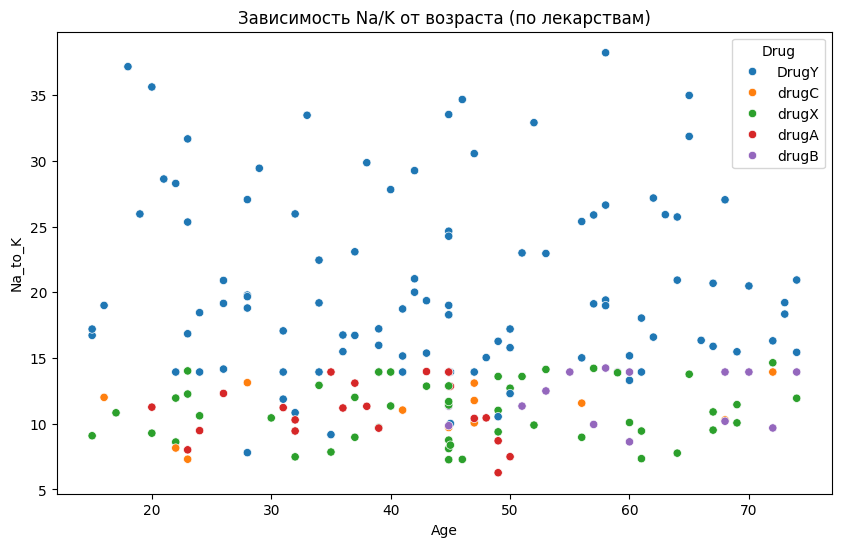

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data = drugsF, x='Age', y='Na_to_K', hue='Drug')
plt.title('Зависимость Na/K от возраста (по лекарствам)')
plt.show()

In [27]:
fig = px.box(drugsF, x='Age', y='Na_to_K', color='Drug',
            hover_data=['Sex', 'BP', 'Cholesterol'],
            title='ящик с усами')
fig.show()

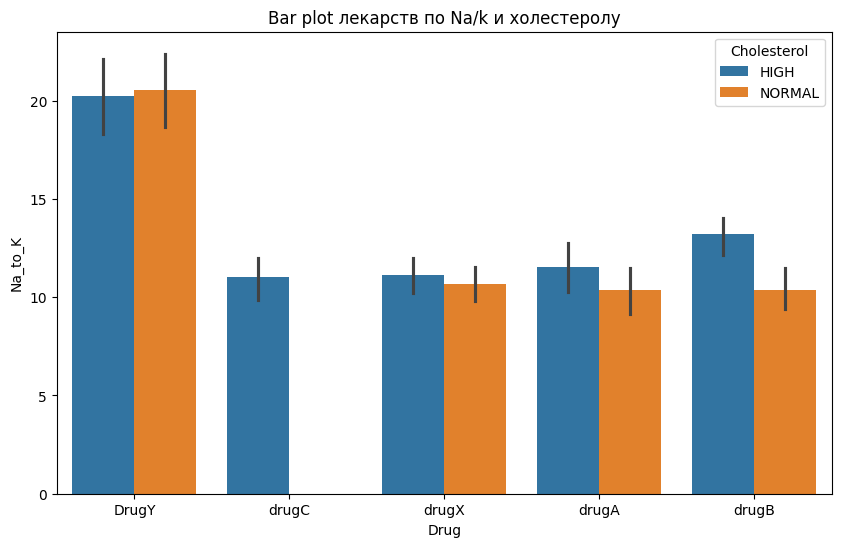

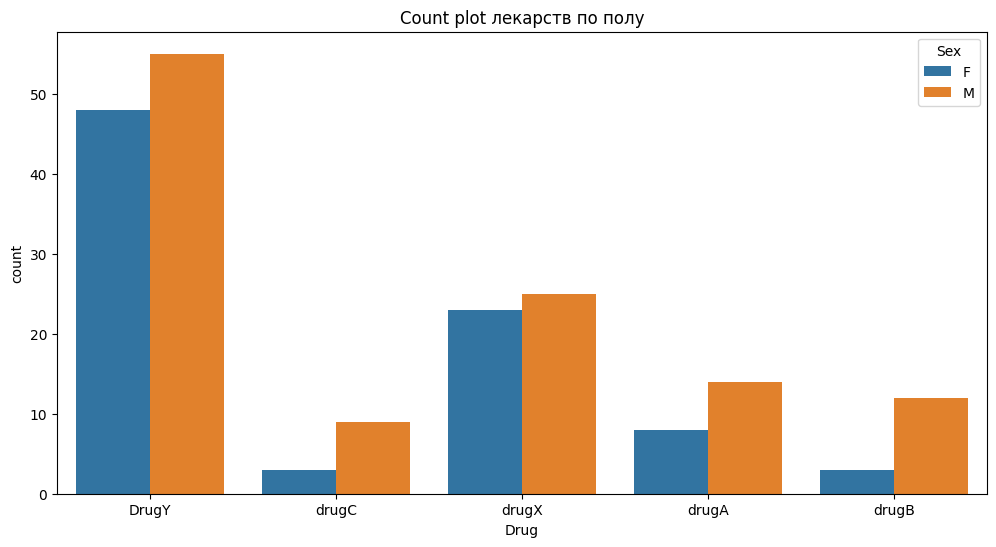

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=drugsF, x='Drug', y='Na_to_K', hue='Cholesterol')
plt.title('Bar plot лекарств по Na/k и холестеролу')
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=drugsF, x='Drug', hue='Sex')
plt.title('Count plot лекарств по полу')
plt.show()

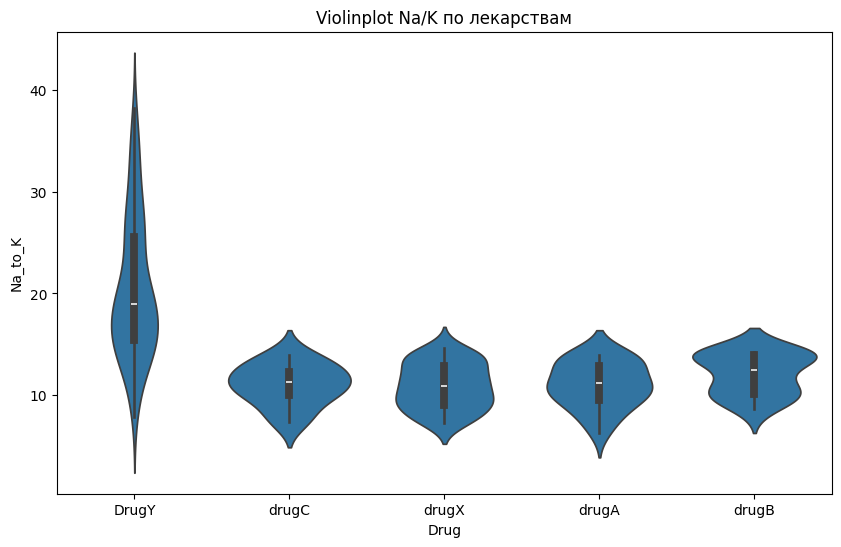

In [48]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=drugsF, x='Drug', y='Na_to_K')
plt.title('Violinplot Na/K по лекарствам')
plt.show()

<Figure size 1000x600 with 0 Axes>

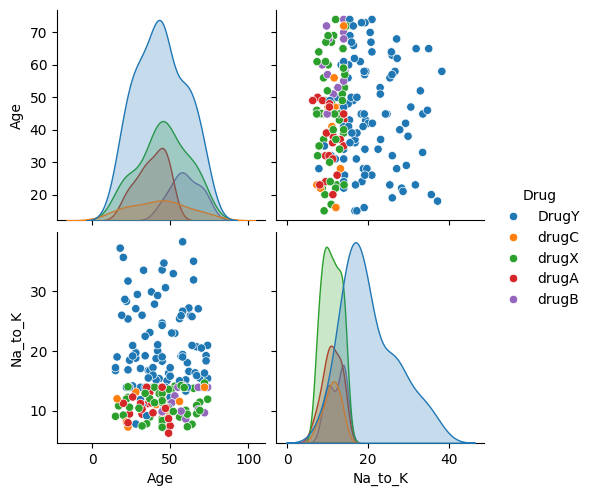

In [51]:
plt.figure(figsize=(10, 6))
sns.pairplot(drugsF, hue='Drug')
plt.show()

Матрица корелляций. Из неё видно, что ничего толком то и не кореллирует, за исключением неслабой такой зависимости выдаваемого лекарства от кровяного давления. Самая слабая корелляция у Na/K и выдаваемого лекарства.

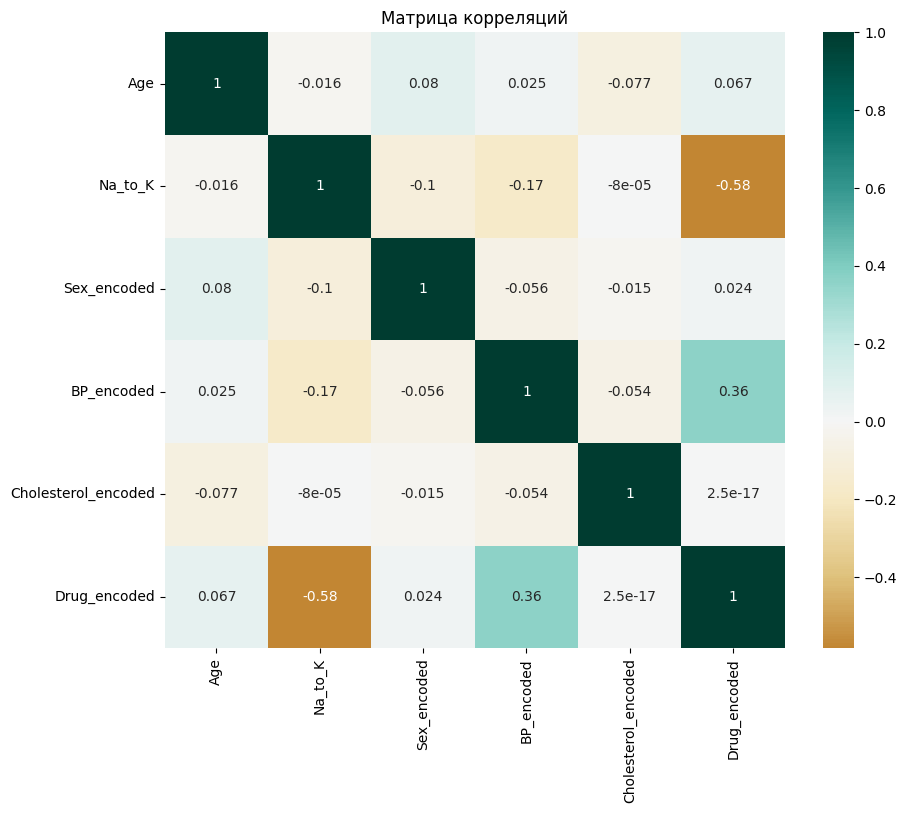

In [54]:
plt.figure(figsize=(10, 8))
numericCols = drugsLE.select_dtypes(include=['number'])
correlation = numericCols.corr()
sns.heatmap(correlation, annot=True, cmap='BrBG', center=0)
plt.title('Матрица корреляций')
plt.show()


### Про датасет можно сказать:

* В датасете 200 записей, нет пропусков (для изучения функционала предложенных библиотек пропуски были созданы искусственно)
* Возраст пациентов распределен равномерно в промежутке от 15 до 74 лет
* Распределение Na/K куда менее равномерное, есть выбросы
* Чуть больше половины пациентов имеют высокий холестерол, чуть больше трети пациентов имеют повышенное кровяное давлление
* Лекарство C не назначалось при нормальном холестероле
* Присутствует связь назначаемых лекарств с кровяным давлением
* Лекарство Y назначалось чаще всего, причем оно единственное, которое назначалось чаще при нормальном холестероле.



В дальнейшем я бы попытался найти похожий датасет, но чуть больший размером и с более конкретными данными для прогнозирования выдачи реальных лекарств. Было бы крайне интересно самостоятельно измерять показатели и наблюдать результат.

При выполнении работы ии использовался для технических моментов, как правило связанных с синтаксисом python, а также для уточнения аргументов функций используемых библиотек.
В остальном, все написано самостоятельно.